In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.physics.em.mt1dmodelling import (MT1dBlockModelling,
                                              MT1dSmoothModelling)

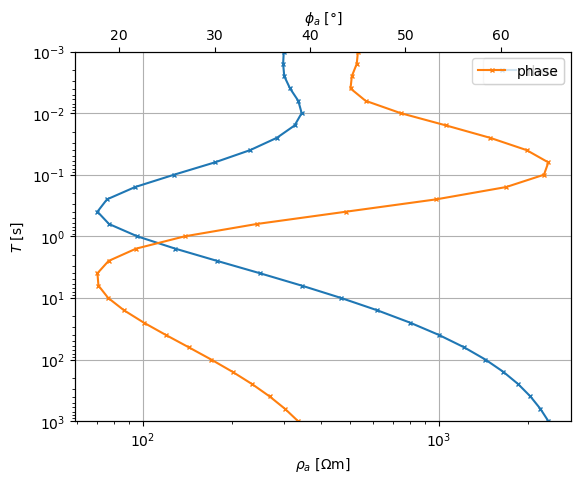

In [2]:
thkS = [1000, 1000]
resS = [300, 30, 3000]
T = np.logspace(-3, 3, 31)
fB = MT1dBlockModelling(T, len(resS))
model = np.array(thkS+resS)
data = fB(model)
fig, ax = plt.subplots()
fB.drawData(ax, data)

In [3]:
errRho = 0.03
rhoaN = data[:len(T)] * (np.random.randn(len(T))*errRho + 1)
errPhi = np.deg2rad(1)
phiaN = data[len(T):] + np.random.randn(len(T))*errPhi
dataN = pg.cat(rhoaN, phiaN)
relativeError = pg.cat(np.ones_like(T)*errRho, np.ones_like(T)*errRho/data[len(data)//2:])

In [4]:
invB = pg.frameworks.MarquardtInversion(fop=fB)
modelB = invB.run(dataN, relativeError=relativeError, verbose=True)

27/10/25 - 10:51:22 - pyGIMLi - INFO - Created startmodel from forward operator:5, min/max=37.101126/1000.000000
27/10/25 - 10:51:22 - pyGIMLi - INFO - Starting inversion.
27/10/25 - 10:51:22 - pyGIMLi - WARNING - Multiprocess Jacobian currently unavailable for Win32 and Mac.
27/10/25 - 10:51:22 - pyGIMLi - WARNING - Multiprocess Jacobian currently unavailable for Win32 and Mac.
27/10/25 - 10:51:22 - pyGIMLi - WARNING - Multiprocess Jacobian currently unavailable for Win32 and Mac.
27/10/25 - 10:51:22 - pyGIMLi - WARNING - Multiprocess Jacobian currently unavailable for Win32 and Mac.
27/10/25 - 10:51:22 - pyGIMLi - WARNING - Multiprocess Jacobian currently unavailable for Win32 and Mac.
27/10/25 - 10:51:22 - pyGIMLi - WARNING - Multiprocess Jacobian currently unavailable for Win32 and Mac.
27/10/25 - 10:51:22 - pyGIMLi - WARNING - Multiprocess Jacobian currently unavailable for Win32 and Mac.


fop: <pygimli.physics.em.mt1dmodelling.MT1dBlockModelling object at 0x000001603E4658F0>
Data transformation: Identity transform
Model transformation (cumulative):
	 0 Logarithmic LU transform, lower bound 0.0, upper bound 0.0
	 1 Logarithmic LU transform, lower bound 0.0, upper bound 0.0
min/max (data): 0.3/2421
min/max (error): 2.64%/9.7%
min/max (start model): 37.1/1000
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  445.20
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  211.09 (dPhi = 52.58%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   31.06 (dPhi = 85.29%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.39 (dPhi = 95.54%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² = 

In [5]:
thk = np.arange(100, 500, 21)
fS = MT1dSmoothModelling(T, thk)
rho = np.ones(len(thk)+1) * 100

27/10/25 - 10:51:23 - pyGIMLi - INFO - Found 1 regions.


In [6]:
invS = pg.Inversion(fop=fS)
modelS = invS.run(dataN, relativeError=relativeError, verbose=True)

27/10/25 - 10:51:23 - pyGIMLi - INFO - Created startmodel from forward operator:21, min/max=37.101126/37.101126
27/10/25 - 10:51:23 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.em.mt1dmodelling.MT1dSmoothModelling object at 0x000001603EE33F60>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 0.3/2421
min/max (error): 2.64%/9.7%
min/max (start model): 37.1/37.1
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  445.20
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  356.48 (dPhi = 19.91%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =  220.38 (dPhi = 38.09%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =   61.20 (dPhi = 71.89%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    6.24 (dPhi = 87.22%) lam: 20.0
--------------------------------------------------------------------------------
i

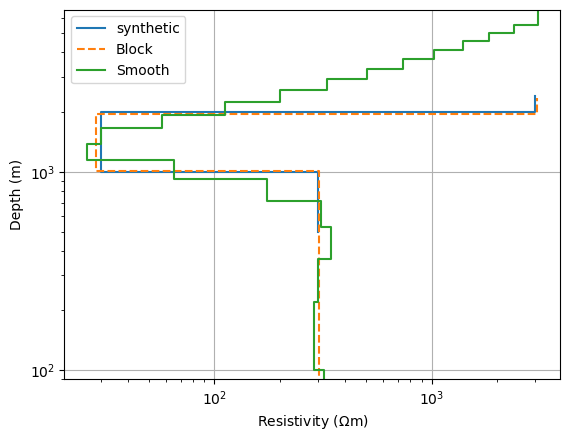

In [23]:
fig, ax = plt.subplots()
pg.viewer.mpl.drawModel1D(ax, model=model, label='synthetic', plot='loglog')
pg.viewer.mpl.drawModel1D(ax, model=modelB, label='Block', ls='--')
pg.viewer.mpl.drawModel1D(ax, thickness=thk, values=modelS, label='Smooth')
ax.legend()
ax.set_ylim(thk[0]*0.9, sum(thk)*1.1);

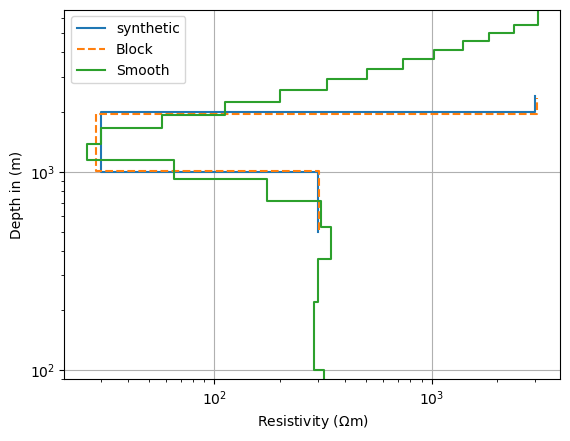

In [20]:
fig, ax = plt.subplots()
fB.drawModel(ax, model, label='synthetic')
fB.drawModel(ax, modelB, label='Block', ls='--')
fS.drawModel(ax, modelS, label='Smooth')
ax.set_ylim(thk[0]*0.9, sum(thk)*1.1);
ax.legend()